# Stacking-Based Ensemble for Heart Attack Prediction
## Part 1 - Faithful reproduction on the 1,025-row dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load & verify the dataset

In [2]:
# Kaggle path: /kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv
import os
path = "/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv"
if not os.path.exists(path):
    path = "heart.csv"          # local copy of the same 1,025-row file
df = pd.read_csv(path)

print(df.shape)
print(df.columns.tolist())
assert df.shape == (1025, 14), "Expected the 1,025-row dataset"

features = ["age", "sex", "cp", "trestbps", "chol", "fbs",
            "restecg", "thalach", "exang", "oldpeak",
            "slope", "ca", "thal"]
X = df[features]
y = df["target"]

print("\nMissing values:", int(df.isnull().sum().sum()))
print("Class balance:\n", y.value_counts())
print("Exact duplicate rows:", df.duplicated().sum(), "| unique rows:", len(df.drop_duplicates()))

(1025, 14)
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing values: 0
Class balance:
 target
1    526
0    499
Name: count, dtype: int64
Exact duplicate rows: 723 | unique rows: 302


## 2. Stratified 80/20 split and scaling

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled = scaler.transform(X_test)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (820, 13)  Test: (205, 13)


## 3. Six base classifiers

In [4]:
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "XGBoost":             XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
    "Naive Bayes":         GaussianNB(),
    "KNN":                 KNeighborsClassifier(n_neighbors=7),
}

results, roc_data, preds_store = [], {}, {}
def score(name, y_true, preds, probs):
    return {"Model": name,
            "Accuracy":  accuracy_score(y_true, preds),
            "Precision": precision_score(y_true, preds),
            "Recall":    recall_score(y_true, preds),
            "F1-Score":  f1_score(y_true, preds),
            "ROC-AUC":   roc_auc_score(y_true, probs)}

for name, model in base_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    results.append(score(name, y_test, preds, probs))
    roc_data[name] = roc_curve(y_test, probs)
    preds_store[name] = preds

results_df = pd.DataFrame(results).set_index("Model")
results_df.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298
Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
Naive Bayes,0.8293,0.8070,0.8762,0.8402,0.9043
KNN,0.8439,0.8230,0.8857,0.8532,0.9453


## 4. Stacking ensemble
Meta-classifier: Logistic Regression trained on out-of-fold predictions of the base models (5-fold internal CV).

In [5]:
stack_model = StackingClassifier(
    estimators=list(base_models.items()),
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5, n_jobs=-1,
)
stack_model.fit(X_train_scaled, y_train)
stack_preds = stack_model.predict(X_test_scaled)
stack_probs = stack_model.predict_proba(X_test_scaled)[:, 1]

roc_data["Stacking Ensemble"] = roc_curve(y_test, stack_probs)
preds_store["Stacking Ensemble"] = stack_preds
results_df = pd.concat([results_df,
                        pd.DataFrame([score("Stacking Ensemble", y_test, stack_preds, stack_probs)]).set_index("Model")])
results_df = results_df.round(4)
results_df.sort_values("Accuracy", ascending=False)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
Stacking Ensemble,1.0000,1.0000,1.0000,1.0000,1.0000
Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857
KNN,0.8439,0.8230,0.8857,0.8532,0.9453
Naive Bayes,0.8293,0.8070,0.8762,0.8402,0.9043
Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298


## 5. Published vs. reproduced
Enter the paper's reported values below (`None` = not reported). The comparison table is generated from code, so nothing is hand-copied.

In [6]:
# TODO: fill in from the paper's results table. Only the stacking accuracy (98.53%) is confirmed from the report.
published = {
    "Stacking Ensemble": {"Accuracy": 0.9853, "Precision": None, "Recall": None, "F1-Score": None, "ROC-AUC": None},
    # "Logistic Regression": {"Accuracy": ..., "Precision": ..., "Recall": ..., "F1-Score": ..., "ROC-AUC": ...},
    # ... one entry per model
}
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
rows = []
for m in results_df.index:
    row = {"Model": m}
    for k in metrics:
        pub = published.get(m, {}).get(k)
        row[f"{k} (paper)"] = "n/r" if pub is None else f"{pub:.4f}"
        row[f"{k} (repro)"] = f"{results_df.loc[m, k]:.4f}"
    rows.append(row)
comparison_df = pd.DataFrame(rows).set_index("Model")
comparison_df.to_csv("part1_comparison_table.csv")
results_df.to_csv("part1_reproduced_metrics.csv")
comparison_df

,Accuracy (paper),Accuracy (repro),Precision (paper),Precision (repro),Recall (paper),Recall (repro),F1-Score (paper),F1-Score (repro),ROC-AUC (paper),ROC-AUC (repro)
Model,,,,,,,,,,
Logistic Regression,n/r,0.8098,n/r,0.7619,n/r,0.9143,n/r,0.8312,n/r,0.9298
Decision Tree,n/r,0.9854,n/r,1.0000,n/r,0.9714,n/r,0.9855,n/r,0.9857
Random Forest,n/r,1.0000,n/r,1.0000,n/r,1.0000,n/r,1.0000,n/r,1.0000
XGBoost,n/r,1.0000,n/r,1.0000,n/r,1.0000,n/r,1.0000,n/r,1.0000
Naive Bayes,n/r,0.8293,n/r,0.8070,n/r,0.8762,n/r,0.8402,n/r,0.9043
KNN,n/r,0.8439,n/r,0.8230,n/r,0.8857,n/r,0.8532,n/r,0.9453
Stacking Ensemble,0.9853,1.0000,n/r,1.0000,n/r,1.0000,n/r,1.0000,n/r,1.0000


## 6. Figures

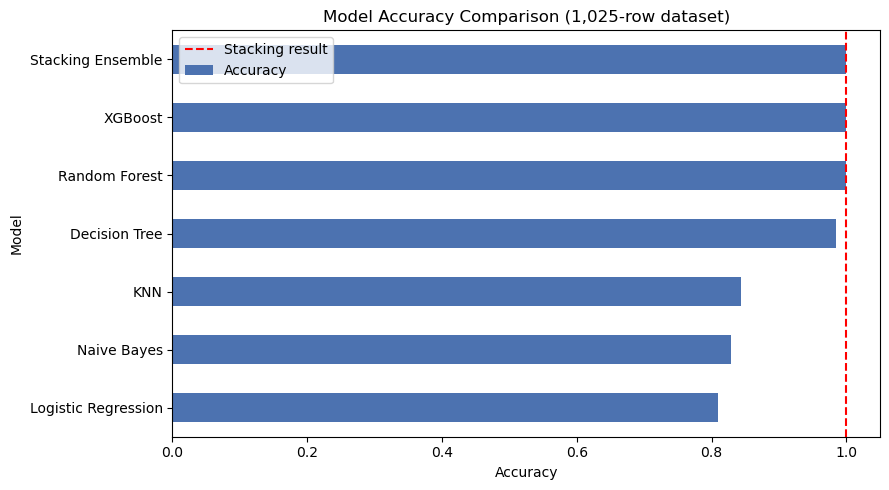

In [7]:
fig, ax = plt.subplots(figsize=(9,5))
results_df["Accuracy"].sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Accuracy"); ax.set_title("Model Accuracy Comparison (1,025-row dataset)")
ax.axvline(results_df.loc["Stacking Ensemble", "Accuracy"], color="red", linestyle="--", label="Stacking result")
ax.legend(); plt.tight_layout(); plt.savefig("fig_accuracy.png", dpi=200); plt.show()

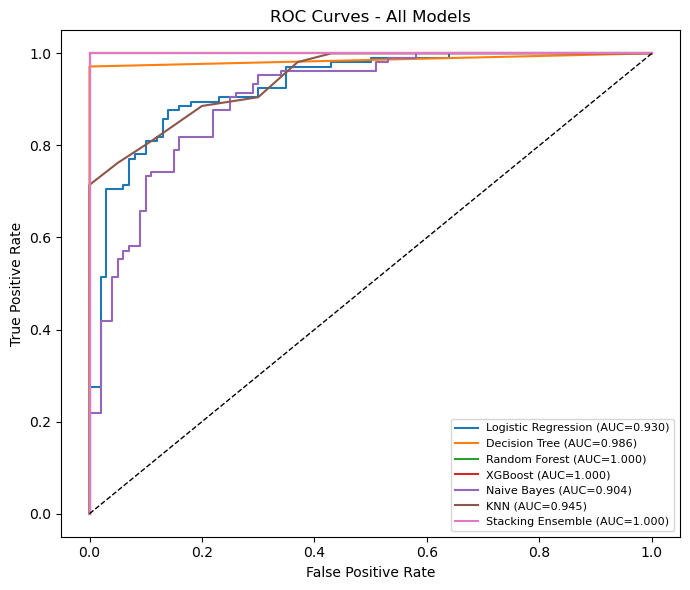

In [8]:
fig, ax = plt.subplots(figsize=(7,6))
for name, (fpr, tpr, _) in roc_data.items():
    ax.plot(fpr, tpr, label=f"{name} (AUC={results_df.loc[name, 'ROC-AUC']:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - All Models"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("fig_roc.png", dpi=200); plt.show()

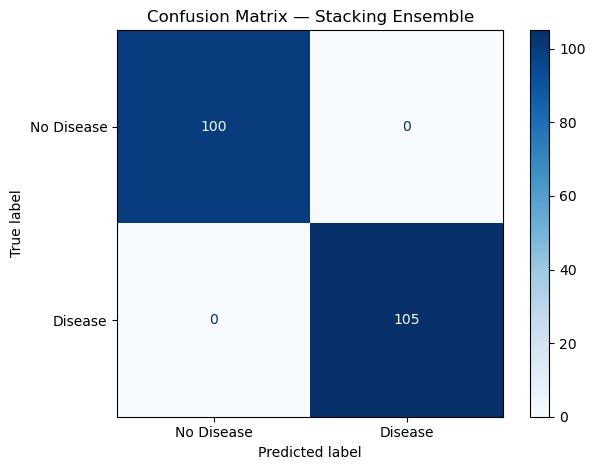

In [9]:
cm = confusion_matrix(y_test, stack_preds)
ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot(cmap="Blues")
plt.title("Confusion Matrix — Stacking Ensemble"); plt.tight_layout()
plt.savefig("fig_confusion_matrix.png", dpi=200); plt.show()

## 7. Sanity check: how much of this score is duplicate leakage?

In [10]:
train_keys = set(map(tuple, X_train.values.tolist()))
in_train = np.array([tuple(r) in train_keys for r in X_test.values.tolist()])
print(f"Test rows with an exact copy in the training set: {in_train.sum()} / {len(X_test)} ({in_train.mean():.1%})")
print(f"Stacking accuracy on those rows:     {accuracy_score(y_test[in_train], stack_preds[in_train]):.4f}")
if (~in_train).any():
    print(f"Stacking accuracy on unseen rows:    {accuracy_score(y_test[~in_train], stack_preds[~in_train]):.4f}  (n={(~in_train).sum()})")

Test rows with an exact copy in the training set: 202 / 205 (98.5%)
Stacking accuracy on those rows:     1.0000
Stacking accuracy on unseen rows:    1.0000  (n=3)
